# דמו מלא: מזני וירוס למועמדים מדורגים

המחברת רצה על רצפים **סינתטיים** בלבד כדי שתוכל להבין כל שלב ולוודא שהקוד עובד.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from viral_safe_target import (
    read_fasta, conservation_profile, find_conserved_runs,
    scan_spcas9_candidates, read_gff3, annotate_candidates,
    screen_against_small_fasta, rank_candidates, write_html_report
)

print("Project root:", ROOT)

Project root: /mnt/data/ViralSafeTarget_Lab


## 1. קוראים את אוסף זני הווירוס

In [2]:
virus_path = ROOT / "data/demo/virus_aligned.fasta"
virus = read_fasta(virus_path)

pd.DataFrame({
    "record_id": list(virus.keys()),
    "alignment_length": [len(x) for x in virus.values()],
    "preview": [x[:45] + "..." for x in virus.values()],
})

,record_id,alignment_length,preview
0,HSV2_demo_ref,170,ATGACCTTAGCTACGATCGTACGATGCTAACCGGTTAACCGGTTA...
1,HSV2_demo_02,170,ATGACCTTAGCTACGATCGTACGATGCTAACCGGTTAACCGGTTA...
2,HSV2_demo_03,170,ATGACCTTAGCTACGATCATACGATGCTAACCGGTTAACCGGTTA...
3,HSV2_demo_04,170,ATGACCTTAGCTACGATCGTACGATGCTAACCGGTTAACCGGTTA...
4,HSV2_demo_05,170,ATGACCTTAGCTACGATCGTACGATGCTAACCGGTTAACCGGTTA...


## 2. רואים איפה הרצף שמור בין הזנים

In [3]:
profile = conservation_profile(virus)
runs = find_conserved_runs(profile, identity_threshold=0.80, min_length=20)
runs

,alignment_start_1based,alignment_end_1based,length,mean_identity
0,1,170,170,0.996471


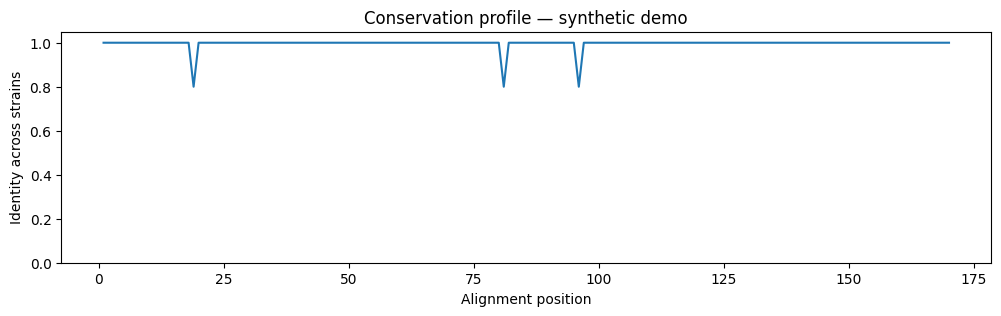

In [4]:
plt.figure(figsize=(12, 3))
plt.plot(profile["alignment_position_1based"], profile["identity_all_sequences"])
plt.ylim(0, 1.05)
plt.xlabel("Alignment position")
plt.ylabel("Identity across strains")
plt.title("Conservation profile — synthetic demo")
plt.show()

## 3. סורקים אתרי SpCas9

הפונקציה מחפשת בשני הגדילים מטרה של 20 אותיות ולידה PAM מסוג `NGG`, ומחשבת בכמה מהזנים כל האתר בן 23 האותיות נשמר בדיוק.

In [5]:
candidates = scan_spcas9_candidates(
    virus,
    reference_id="HSV2_demo_ref",
    min_site_coverage=0.0,
)

candidates[[
    "candidate_id", "reference_start_1based", "strand", "guide_sequence",
    "pam", "virus_site_coverage", "exact_genome_count", "genome_count"
]]

,candidate_id,reference_start_1based,strand,guide_sequence,pam,virus_site_coverage,exact_genome_count,genome_count
0,T00001,12,+,TACGATCGTACGATGCTAAC,CGG,0.8,4,5
1,T00002,20,+,TACGATGCTAACCGGTTAAC,CGG,1.0,5,5
2,T00003,29,+,AACCGGTTAACCGGTTAACC,AGG,1.0,5,5
3,T00004,88,+,TTGCAACGTTGCAACGTTGC,TGG,0.8,4,5
4,T00005,8,-,GCATCGTACGATCGTAGCTA,AGG,0.8,4,5
5,T00006,34,-,TACCTGGTTAACCGGTTAAC,CGG,1.0,5,5
6,T00007,42,-,ATCGATCGTACCTGGTTAAC,CGG,1.0,5,5
7,T00008,50,-,TAGCTAGCATCGATCGTACC,TGG,1.0,5,5


## 4. מוסיפים משמעות מה־GFF3

In [6]:
gff = read_gff3(ROOT / "data/demo/reference.gff3")
annotated = annotate_candidates(candidates, gff, seqid="HSV2_demo_ref")

annotated[[
    "candidate_id", "reference_start_1based", "gene_name", "product",
    "feature_type", "virus_site_coverage"
]]

,candidate_id,reference_start_1based,gene_name,product,feature_type,virus_site_coverage
0,T00001,12,DEMO_A,demo replication protein,CDS,0.8
1,T00002,20,DEMO_A,demo replication protein,CDS,1.0
2,T00003,29,DEMO_A,demo replication protein,CDS,1.0
3,T00004,88,DEMO_B,demo structural protein,CDS,0.8
4,T00005,8,DEMO_A,demo replication protein,CDS,0.8
5,T00006,34,DEMO_A,demo replication protein,CDS,1.0
6,T00007,42,DEMO_A,demo replication protein,CDS,1.0
7,T00008,50,DEMO_A,demo replication protein,CDS,1.0


## 5. מסננים מול “גנום אדם” קטן

כאן משתמשים ב־FASTA סינתטי קטן כדי להבין את הרעיון. על GRCh38 המלא **לא** משתמשים בלולאה הזאת; עוברים ל־Cas-OFFinder או מנוע genome-scale אחר.

In [7]:
human_demo = read_fasta(ROOT / "data/demo/human_mini.fasta")
screened = screen_against_small_fasta(
    annotated,
    human_demo,
    max_mismatches=3,
)

screened[[
    "candidate_id", "guide_sequence", "host_exact_matches",
    "host_matches_le_3_mismatches", "host_min_mismatches", "host_best_location"
]]

,candidate_id,guide_sequence,host_exact_matches,host_matches_le_3_mismatches,host_min_mismatches,host_best_location
0,T00001,TACGATCGTACGATGCTAAC,0,0,NaN,
1,T00002,TACGATGCTAACCGGTTAAC,0,0,NaN,
2,T00003,AACCGGTTAACCGGTTAACC,1,1,0.0,chrDemo1:37-56(+)
3,T00004,TTGCAACGTTGCAACGTTGC,0,1,2.0,chrDemo2:47-66(+)
4,T00005,GCATCGTACGATCGTAGCTA,0,0,NaN,
5,T00006,TACCTGGTTAACCGGTTAAC,0,1,1.0,chrDemo1:42-61(-)
6,T00007,ATCGATCGTACCTGGTTAAC,0,0,NaN,
7,T00008,TAGCTAGCATCGATCGTACC,0,0,NaN,


## 6. דירוג שקוף

הציון כאן הוא **הדגמה הנדסית בלבד**, לא נוסחת בטיחות מדעית. היתרון הוא שכל רכיב נשמר בנפרד ואפשר להחליף אותו בהמשך במדד מאומת.

In [8]:
ranked = rank_candidates(screened)
columns = [
    "candidate_id", "gene_name", "guide_sequence", "pam",
    "virus_site_coverage", "host_exact_matches", "host_min_mismatches",
    "human_safety_component", "demo_score", "decision"
]
ranked[columns]

,candidate_id,gene_name,guide_sequence,pam,virus_site_coverage,host_exact_matches,host_min_mismatches,human_safety_component,demo_score,decision
0,T00002,DEMO_A,TACGATGCTAACCGGTTAAC,CGG,1.0,0,NaN,1.00,1.0000,prioritize_for_literature_review
1,T00007,DEMO_A,ATCGATCGTACCTGGTTAAC,CGG,1.0,0,NaN,1.00,1.0000,prioritize_for_literature_review
2,T00008,DEMO_A,TAGCTAGCATCGATCGTACC,TGG,1.0,0,NaN,1.00,1.0000,prioritize_for_literature_review
3,T00001,DEMO_A,TACGATCGTACGATGCTAAC,CGG,0.8,0,NaN,1.00,0.8800,review
4,T00005,DEMO_A,GCATCGTACGATCGTAGCTA,AGG,0.8,0,NaN,1.00,0.8800,review
5,T00006,DEMO_A,TACCTGGTTAACCGGTTAAC,CGG,1.0,0,1.0,0.25,0.8125,review
6,T00004,DEMO_B,TTGCAACGTTGCAACGTTGC,TGG,0.8,0,2.0,0.50,0.7550,review
7,T00003,DEMO_A,AACCGGTTAACCGGTTAACC,AGG,1.0,1,0.0,0.00,0.7500,reject_demo_exact_host_match


## 7. שומרים CSV ודוח HTML

In [9]:
out_dir = ROOT / "reports/demo_notebook"
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "candidates.csv"
html_path = out_dir / "report.html"
ranked.to_csv(csv_path, index=False)
write_html_report(ranked, html_path, title="ViralSafeTarget — synthetic demo")

print("CSV:", csv_path)
print("HTML:", html_path)

CSV: /mnt/data/ViralSafeTarget_Lab/reports/demo_notebook/candidates.csv
HTML: /mnt/data/ViralSafeTarget_Lab/reports/demo_notebook/report.html


## מה למדנו מהדמו?

- FASTA נותן את האותיות.
- alignment מאפשר למדוד שמירות בין זנים.
- PAM קובע אילו מקומות מתאימים ל־SpCas9.
- GFF מסביר באיזה גן נמצא האתר.
- השוואה לאדם מסמנת סיכוני off-target.
- הרשימה הסופית היא רשימת מועמדים לבדיקת ספרות וניסוי — לא תרופה.